# DS-Wave non-adaptive testing

Standalone DS-Wave target solving and toroidal point synthesis.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # For Windows

import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [2]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np

module_path = Path("ds-wave.py").resolve()
if not module_path.exists():
	module_path = Path("python") / "ds-wave.py"
module_path = module_path.resolve()
spec = importlib.util.spec_from_file_location("ds_wave", module_path)
ds_wave = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ds_wave)

plt.rcParams["figure.dpi"] = 120

In [3]:
# Easy-to-edit parameters
nu0 = 0.85
e0 = 0.0
nu_max = 10.0
n_nu = 1001
n_r = 128
n_points = 2048
iterations = 1000
seed = 1234
m0_values = [1.0, 2.0, "min"]
device = "auto"
spectrum_learning_rate = 0.03
mode_limit = 12000
mode_chunk_size = 512
low_frequency_weight = 50.0

# Options: ds_wave.SynthesisMode.SPECTRUM_MATCHING or ds_wave.SynthesisMode.PCF_MATCHING
synthesis_mode = ds_wave.SynthesisMode.PCF_MATCHING
pcf_step_scale = 1.0
pcf_num_bins = None  # None uses n_points, matching targetrdf
pcf_smoothing = 8.0  # RDF Gaussian smoothing in bins, matching targetrdf default
pcf_chunk_size = 256
initial_points = None

m0=1.0: infeasible - The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
m0=2.0: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)
m0=min: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)


C:\Users\ville\AppData\Local\Temp\ipykernel_46612\2157386874.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


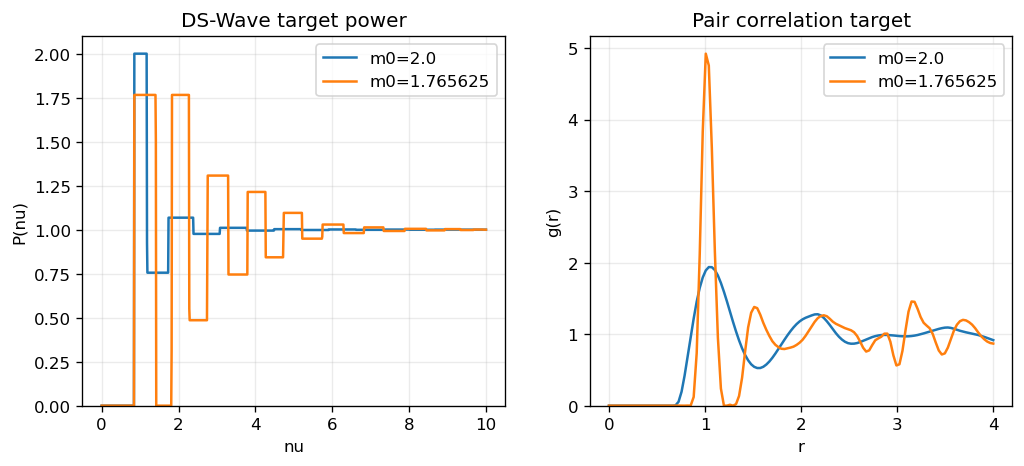

In [4]:
targets = {}
for m0 in m0_values:
	target = ds_wave.solve_ds_wave_target(
		nu0=nu0,
		e0=e0,
		m0=m0,
		nu_max=nu_max,
		n_nu=n_nu,
		n_r=n_r,
		require_success=False,
	)
	targets[str(m0)] = target
	print(f"m0={m0}: {target['status']} - {target['message']}")

fig = ds_wave.plot_ds_wave_targets(list(targets.values()))
fig.show()

In [5]:
print(targets.keys())
min_target = targets["min"]
if not min_target["success"]:
	raise RuntimeError(min_target["message"])

synthesis = ds_wave.synthesize_toroidal_points(
	min_target,
	n_points=n_points,
	iterations=iterations,
	seed=seed,
	device=device,
	spectrum_learning_rate=spectrum_learning_rate,
	mode_limit=mode_limit,
	mode_chunk_size=mode_chunk_size,
	low_frequency_weight=low_frequency_weight,
	synthesis_mode=synthesis_mode,
	pcf_step_scale=pcf_step_scale,
	pcf_num_bins=pcf_num_bins,
	pcf_smoothing=pcf_smoothing,
	pcf_chunk_size=pcf_chunk_size,
	initial_points=initial_points,
	log_every=max(100, 1),
)
points = synthesis["points"]
print(f"mode={synthesis['synthesis_mode']}, device={synthesis['device']}, final energy={synthesis['energy_history'][-1]:.6g}")
print(points.shape, points.min(), points.max())
print(synthesis["iterations_run"])
print(len(synthesis["energy_history"]))

print("Energy history:")
for e in synthesis["energy_history"][-10:]:
	print(e)

dict_keys(['1.0', '2.0', 'min'])
mode=pcf_matching, device=cuda, final energy=0.0219866
(2048, 2) 0.0001793654 0.99895227
1000
11
Energy history:
0.04304295253352637
0.022471352189980556
0.022012524180469204
0.021986608525116153
0.021986608525116153
0.021986608525116153
0.021986608525116153
0.021986608525116153
0.021986608525116153
0.021986608525116153


C:\Users\ville\AppData\Local\Temp\ipykernel_46612\3835064014.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


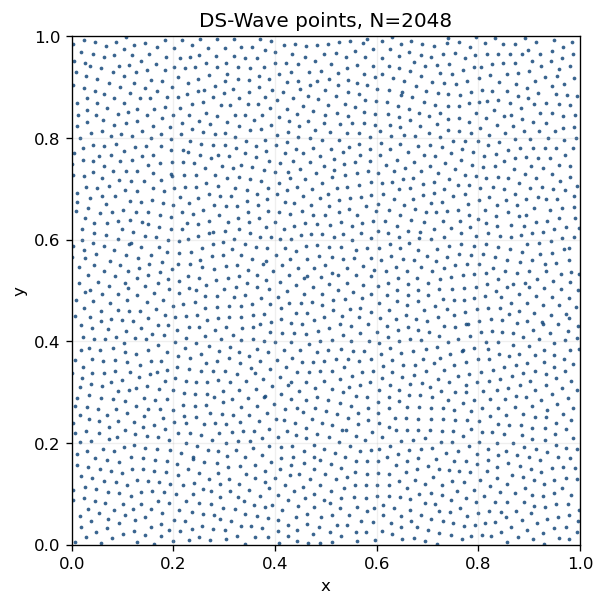

In [6]:
fig = ds_wave.plot_points(points, title=f"DS-Wave points, N={n_points}")
fig.show()

C:\Users\ville\AppData\Local\Temp\ipykernel_46612\3426012565.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


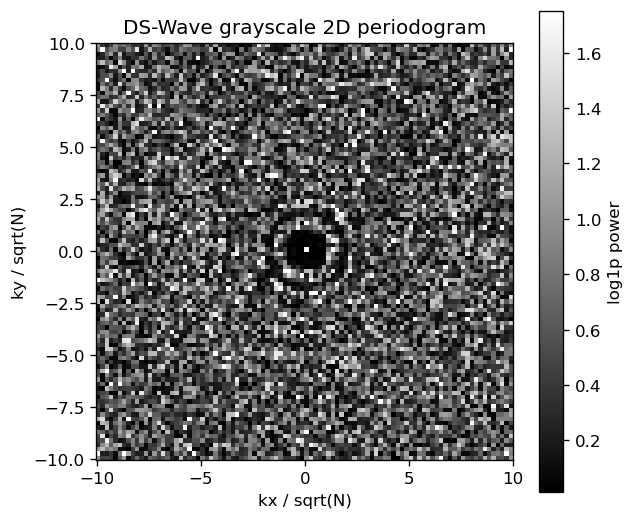

In [7]:
power_2d, extent = ds_wave.compute_periodogram_2d(points, grid_size=96, max_freq=nu_max)
fig = ds_wave.plot_periodogram(power_2d, extent, title="DS-Wave grayscale 2D periodogram")
fig.show()

C:\Users\ville\AppData\Local\Temp\ipykernel_46612\2930057178.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


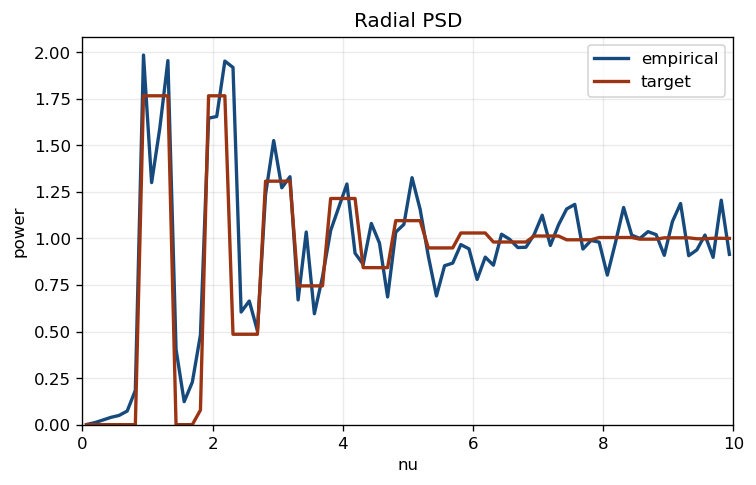

In [8]:
fig = ds_wave.plot_radial_psd_overlay(points, min_target, max_freq=nu_max)
fig.show()

C:\Users\ville\AppData\Local\Temp\ipykernel_46612\3071173755.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


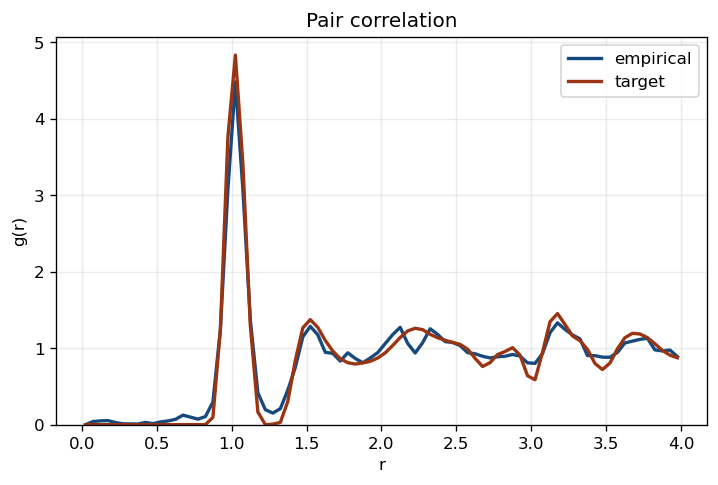

In [9]:
fig = ds_wave.plot_pcf_overlay(points, min_target)
fig.show()